In [15]:
# ==============================================================================
# INTRODUCAO E DEFINICAO DO PROBLEMA 🚗💡
# ==============================================================================

def imprimir_introducao():
    texto = """
    ================================================================================
    🚗✨ PAINEL DE PREVISAO E ANALISE DE CARROS USADOS NO BRASIL ✨🚗
    ================================================================================

    📌 DEFINICAO DO PROBLEMA:
    --------------------
    O mercado secundario de automoveis no Brasil e altamente fragmentado, com precos
    variando significativamente com base na idade do veiculo, quilometragem, cilindrada (cc),
    tipo de combustivel e transmissao. Esta analise constroi um pipeline completo de
    Machine Learning e Analise Exploratoria de Dados (AED) para prever com precisao
    os precos de carros usados (Preco em R$) e descobrir dinamicas ocultas do mercado.

    🎯 OBJETIVOS PRINCIPAIS:
    --------------------
    1. 📊 Realizar Analise Exploratoria de Dados (AED) abrangente com 50+ graficos.
    2. 🛠️ Executar limpeza de dados, extracao de features e pre-processamento.
    3. ⚙️ Criar features especificas do dominio (ex: Idade do Veiculo, Preco por CC, Densidade de Km).
    4. 🤖 Treinar, comparar e avaliar multiplos modelos de ML (Linear, baseados em Arvore, Ensembles).
    5. 🔍 Explicar decisoes do modelo usando importancia de features SHAP e LIME.
    6. 🚀 Descobrir anomalias de mercado, padroes de clustering e tendencias temporais.

    📂 VISAO GERAL DO DATASET:
    -------------------
    * Dataset Principal: Carros_Usados_Brasil.csv (19.852 registros)
    * Features Principais:
        - Nome do Carro     : Metadados de Marca e Modelo
        - Ano do Modelo     : Ano de fabricacao
        - Quilometragem     : Distancia total percorrida (km)
        - Tipo Combustivel  : Gasolina, Diesel, Hibrido, GNV, Eletrico
        - Cilindrada        : Tamanho do motor em cc
        - Transmissao       : Automatico vs Manual
        - Preco (R$)        : VARIAVEL ALVO (Preco de Venda do Veiculo)

    ================================================================================
    """
    print(texto)

imprimir_introducao()


    🚗✨ PAINEL DE PREVISAO E ANALISE DE CARROS USADOS NO BRASIL ✨🚗

    📌 DEFINICAO DO PROBLEMA:
    --------------------
    O mercado secundario de automoveis no Brasil e altamente fragmentado, com precos
    variando significativamente com base na idade do veiculo, quilometragem, cilindrada (cc),
    tipo de combustivel e transmissao. Esta analise constroi um pipeline completo de
    Machine Learning e Analise Exploratoria de Dados (AED) para prever com precisao
    os precos de carros usados (Preco em R$) e descobrir dinamicas ocultas do mercado.

    🎯 OBJETIVOS PRINCIPAIS:
    --------------------
    1. 📊 Realizar Analise Exploratoria de Dados (AED) abrangente com 50+ graficos.
    2. 🛠️ Executar limpeza de dados, extracao de features e pre-processamento.
    3. ⚙️ Criar features especificas do dominio (ex: Idade do Veiculo, Preco por CC, Densidade de Km).
    4. 🤖 Treinar, comparar e avaliar multiplos modelos de ML (Linear, baseados em Arvore, Ensembles).
    5. 🔍 Explicar deci

In [16]:
import pandas as pd
import numpy as np

# Descricao: Carregar dataset, tratar valores ausentes, remover colunas redundantes,
# criar features basicas e exibir estatisticas resumidas essenciais.

print("📌 Carregando Dataset...")
df = pd.read_csv('Carros_Usados_Brasil.csv') # Corrected filename

# Remover artefatos de indexacao, se presentes
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# Renomear colunas para portugues e adaptar para contexto brasileiro
df.rename(columns={
    'Car Name': 'Nome_Carro',
    'Model Year': 'Ano_Modelo',
    'Mileage': 'Quilometragem',
    'Fuel Type': 'Tipo_Combustivel', # Corrected original column name
    'Engine Capacity': 'Cilindrada',
    'Transmission': 'Transmissao', # Corrected original column name
    'Price': 'Preco_BRL' # Corrected original column name
}, inplace=True)

# Traduzir valores categoricos (assuming they might still be in English in the new dataset)
df['Tipo_Combustivel'] = df['Tipo_Combustivel'].replace({
    'Petrol': 'Gasolina',
    'Diesel': 'Diesel',
    'Hybrid': 'Hibrido',
    'CNG': 'GNV',
    'Electric': 'Eletrico',
    'LPG': 'GLP',
    'Flex': 'Flex' # Added mapping for 'Flex' type
})
df['Transmissao'] = df['Transmissao'].replace({
    'Automatic': 'Automatico',
    'Manual': 'Manual'
})

print("\n--- 1. PRIMEIRAS 5 LINHAS DO DATASET (df.head()) ---")
print(df.head())

print("\n--- 2. ESTRUTURA E TIPOS DO DATASET (df.info()) ---")
print(df.info())

print("\n--- 3. ESTATISTICAS RESUMIDAS (df.describe()) ---")
print(df.describe().T)

print("\n--- 4. VERIFICACAO DE VALORES AUSENTES (df.isnull().sum()) ---")
print(df.isnull().sum())

# Estrategia de Limpeza
# 1. Remover linhas com variavel alvo ausente (Preco_BRL)
df.dropna(subset=['Preco_BRL'], inplace=True)

# 2. Extrair Nome da Marca de 'Nome_Carro'
df['Marca'] = df['Nome_Carro'].apply(lambda x: str(x).split()[0] if pd.notnull(x) else 'Desconhecido')

# 3. Calcular Idade do Veiculo relativa a 2026
df['Idade_Veiculo'] = 2026 - df['Ano_Modelo']

# Removed 'Avaliacao_Leilao' as it's not a principal feature in the intro.

print("\n--- 5. RESUMO DO DATASET APOS LIMPEZA ---")
print(f"Total de Linhas Restantes: {df.shape[0]}")
print(f"Total de Colunas: {df.shape[1]}")
print("\nValores Ausentes Apos Limpeza:")
print(df.isnull().sum())

📌 Carregando Dataset...

--- 1. PRIMEIRAS 5 LINHAS DO DATASET (df.head()) ---
            Nome_Carro  Ano_Modelo  Quilometragem Tipo_Combustivel  \
0  Chevrolet Onix Plus        2021          35000             Flex   
1            Fiat Argo        2020          48000             Flex   
2        Hyundai Creta        2022          22000             Flex   
3        Jeep Renegade        2021          41000             Flex   
4         Nissan Kicks        2023          15000             Flex   

   Cilindrada Transmissao  Preco_BRL  
0        1000      Manual      68500  
1        1300      Manual      55000  
2        2000  Automatico     112000  
3        1800  Automatico      95000  
4        1600  Automatico     105000  

--- 2. ESTRUTURA E TIPOS DO DATASET (df.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Nome_Carro     

# Modelos de Machine Learning e Avaliação 🤖📈

Nesta seção, prepararemos os dados para o treinamento de modelos, definiremos e avaliaremos diversos modelos de regressão, incluindo o K-Nearest Neighbors (KNN), e visualizaremos seus resultados para identificar o melhor desempenho.

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Preparacao dos dados
features_cat = ['Tipo_Combustivel', 'Transmissao', 'Marca']
features_num = ['Cilindrada', 'Quilometragem', 'Idade_Veiculo']
alvo = 'Preco_BRL'

df_modelo = df[features_cat + features_num + [alvo]].dropna()
X = df_modelo[features_cat + features_num]
y = np.log1p(df_modelo[alvo]) # Aplicando logaritmo na variável alvo para normalizar

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

# Pre-processador
# Normaliza features numéricas e aplica OneHotEncoder em categóricas
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), features_num),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_cat)
])

print("Dados preparados para Machine Learning:")
print(f"Tamanho de X_treino: {X_treino.shape}")
print(f"Tamanho de y_treino: {y_treino.shape}")
print(f"Tamanho de X_teste: {X_teste.shape}")
print(f"Tamanho de y_teste: {y_teste.shape}")

Dados preparados para Machine Learning:
Tamanho de X_treino: (24, 6)
Tamanho de y_treino: (24,)
Tamanho de X_teste: (6, 6)
Tamanho de y_teste: (6,)



--- Avaliando Modelos de Machine Learning ---
Regressao Linear: R2=0.6971, RMSE=0.2582, MAE=0.2473
Ridge: R2=0.8116, RMSE=0.2037, MAE=0.1744
Lasso: R2=0.5328, RMSE=0.3207, MAE=0.2819
Arvore de Decisao: R2=0.3735, RMSE=0.3714, MAE=0.3200
Random Forest: R2=0.8034, RMSE=0.2081, MAE=0.1764
Gradient Boosting: R2=0.7876, RMSE=0.2162, MAE=0.1887
K-Nearest Neighbors: R2=0.5349, RMSE=0.3200, MAE=0.3003


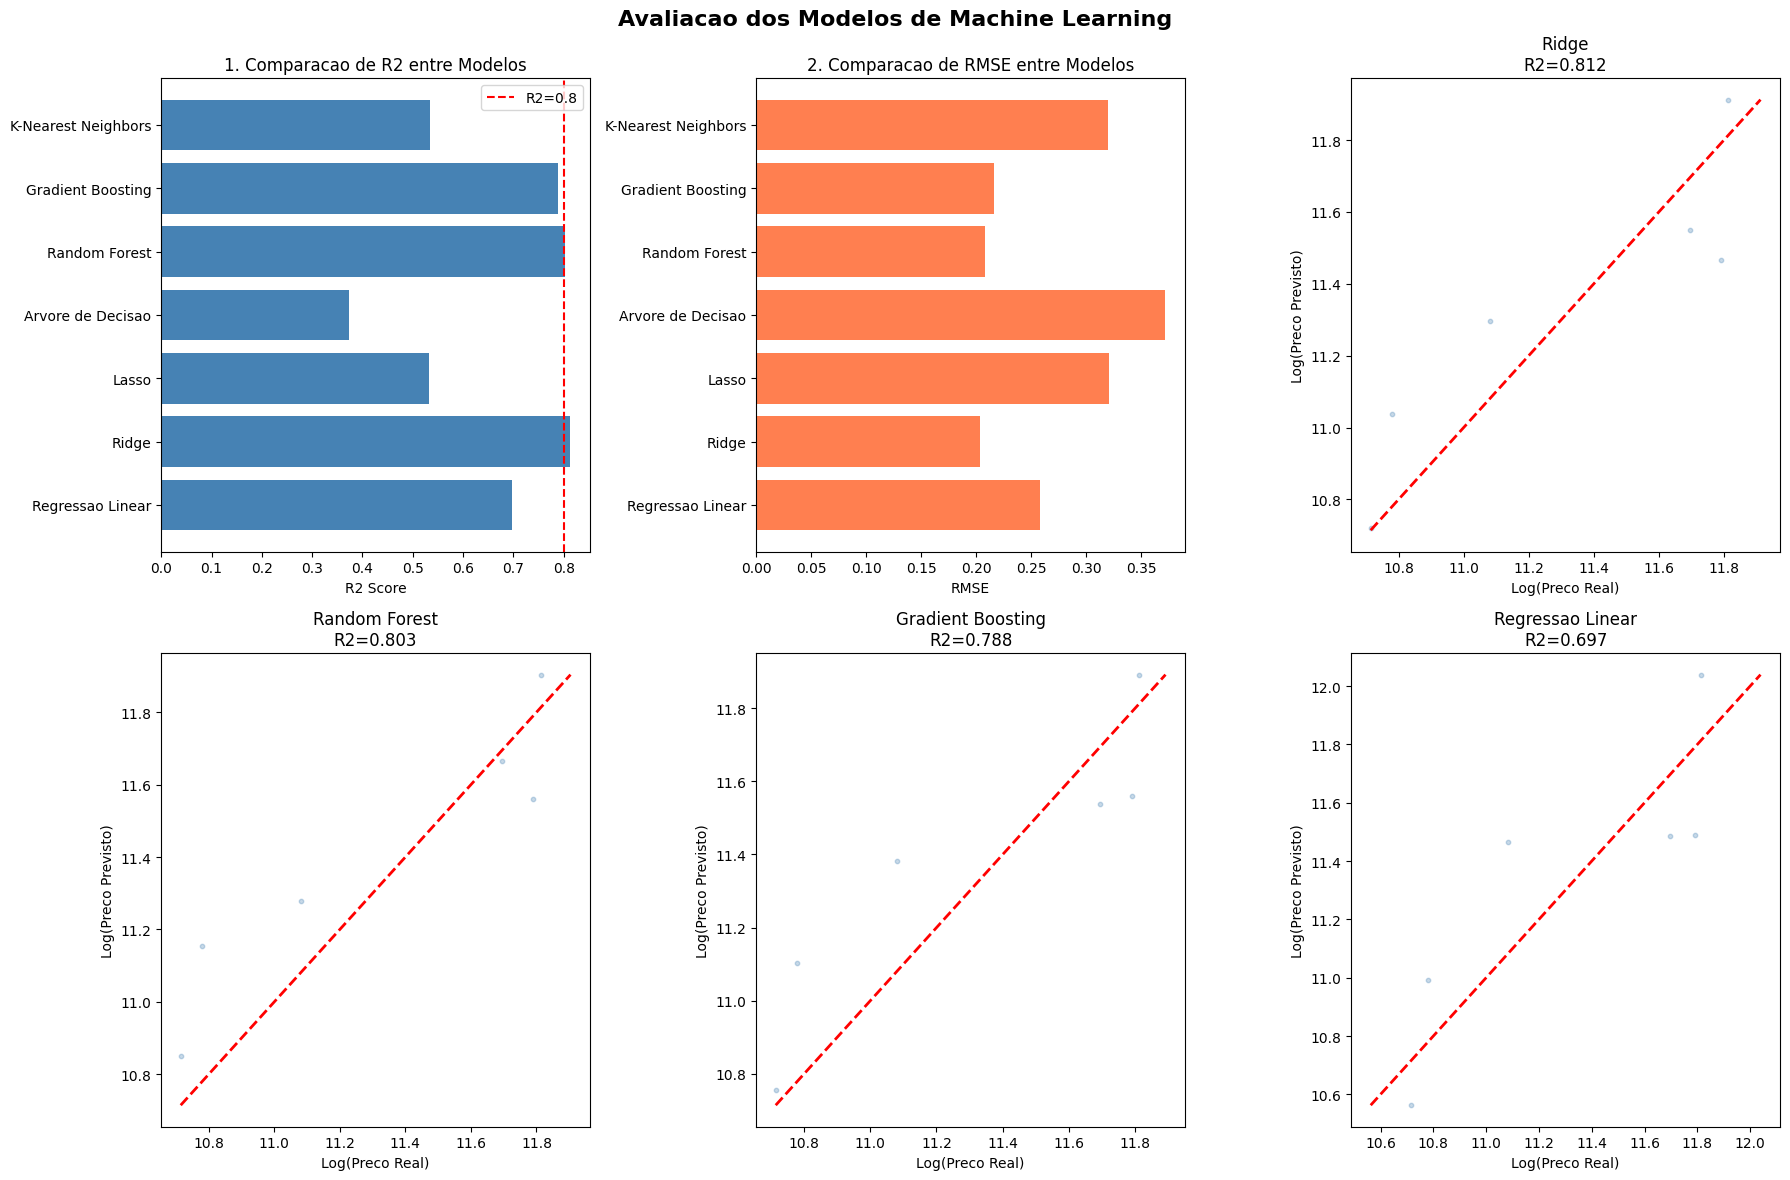

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor # Importando KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Definir modelos, incluindo KNN
modelos = {
    'Regressao Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001),
    'Arvore de Decisao': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsRegressor(n_neighbors=5) # Adicionando KNN
}

resultados = {}
print("\n--- Avaliando Modelos de Machine Learning ---")
for nome, modelo in modelos.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', modelo)])
    pipeline.fit(X_treino, y_treino)
    y_pred = pipeline.predict(X_teste)
    r2 = r2_score(y_teste, y_pred)
    rmse = np.sqrt(mean_squared_error(y_teste, y_pred))
    mae = mean_absolute_error(y_teste, y_pred)
    resultados[nome] = {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'pipeline': pipeline}
    print(f"{nome}: R2={r2:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}")

# Graficos de Avaliacao
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

nomes_modelos = list(modelos.keys())
r2_scores = [resultados[n]['R2'] for n in nomes_modelos]
rmse_scores = [resultados[n]['RMSE'] for n in nomes_modelos]

# Grafico 1: Comparacao de R2
axes[0,0].barh(nomes_modelos, r2_scores, color='steelblue')
axes[0,0].set_title('1. Comparacao de R2 entre Modelos')
axes[0,0].set_xlabel('R2 Score')
axes[0,0].axvline(x=0.8, color='red', linestyle='--', label='R2=0.8')
axes[0,0].legend()

# Grafico 2: Comparacao de RMSE
axes[0,1].barh(nomes_modelos, rmse_scores, color='coral')
axes[0,1].set_title('2. Comparacao de RMSE entre Modelos')
axes[0,1].set_xlabel('RMSE')

# Graficos 3-6: Previsto vs Real para os 4 melhores modelos
melhores = sorted(resultados.items(), key=lambda x: x[1]['R2'], reverse=True)[:4]
posicoes = [(0,2), (1,0), (1,1), (1,2)] # Adjusted positions to fit in 2x3 grid
for (nome, res), (r, c) in zip(melhores, posicoes):
    pipeline = res['pipeline']
    y_pred = pipeline.predict(X_teste)
    axes[r,c].scatter(y_teste, y_pred, alpha=0.3, color='steelblue', s=10)
    min_val = min(y_teste.min(), y_pred.min())
    max_val = max(y_teste.max(), y_pred.max())
    axes[r,c].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    axes[r,c].set_title(f'{nome}\nR2={res["R2"]:.3f}')
    axes[r,c].set_xlabel('Log(Preco Real)')
    axes[r,c].set_ylabel('Log(Preco Previsto)')

plt.suptitle('Avaliacao dos Modelos de Machine Learning', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Otimização de Hiperparâmetros para KNN ⚙️📊

Para garantir que o modelo K-Nearest Neighbors (KNN) atinja seu melhor desempenho, realizaremos uma otimização de hiperparâmetros. Utilizaremos o `GridSearchCV` para testar diferentes combinações de `n_neighbors` (número de vizinhos) e `weights` (como os vizinhos contribuem para a previsão), buscando a configuração que minimize o erro e maximize a acurácia.

Após a otimização, treinaremos o modelo KNN com os melhores parâmetros encontrados e avaliaremos seu desempenho novamente, comparando-o com os resultados iniciais e os outros modelos.

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("📌 Iniciando otimização de hiperparâmetros para KNN...")

# Definir o modelo KNN
knn = KNeighborsRegressor()

# Definir os hiperparâmetros a serem testados
param_grid = {
    'model__n_neighbors': range(1, 15),  # Testar de 1 a 14 vizinhos
    'model__weights': ['uniform', 'distance'] # Testar pesos uniformes e baseados na distância
}

# Criar um pipeline que inclua o pré-processador e o modelo KNN
pipeline_knn = Pipeline(steps=[('preprocessor', preprocessor), ('model', knn)])

# Configurar o GridSearchCV
grid_search = GridSearchCV(
    pipeline_knn,
    param_grid,
    cv=5, # Usar 5-fold cross-validation
    scoring='r2', # Otimizar para o R2 score
    n_jobs=-1, # Usar todos os cores disponíveis
    verbose=1
)

# Executar a busca pelos melhores hiperparâmetros
grid_search.fit(X_treino, y_treino)

print("\n--- Resultados da Otimização de Hiperparâmetros ---")
print(f"Melhores parâmetros para KNN: {grid_search.best_params_}")
print(f"Melhor R2 score (validação cruzada): {grid_search.best_score_:.4f}")

# Obter o melhor modelo
best_knn_pipeline = grid_search.best_estimator_

# Avaliar o melhor modelo no conjunto de teste
y_pred_knn_tunado = best_knn_pipeline.predict(X_teste)
r2_knn_tunado = r2_score(y_teste, y_pred_knn_tunado)
rmse_knn_tunado = np.sqrt(mean_squared_error(y_teste, y_pred_knn_tunado))
mae_knn_tunado = mean_absolute_error(y_teste, y_pred_knn_tunado)

print(f"\n--- Desempenho do KNN Tunado no Conjunto de Teste ---")
print(f"R2 (KNN Tunado): {r2_knn_tunado:.4f}")
print(f"RMSE (KNN Tunado): {rmse_knn_tunado:.4f}")
print(f"MAE (KNN Tunado): {mae_knn_tunado:.4f}")

# Adicionar os resultados do KNN tunado aos resultados gerais para comparação
resultados['K-Nearest Neighbors (Tunado)'] = {
    'R2': r2_knn_tunado,
    'RMSE': rmse_knn_tunado,
    'MAE': mae_knn_tunado,
    'pipeline': best_knn_pipeline
}

# Atualizar a lista de modelos e scores para o gráfico de comparação
nomes_modelos_atualizados = list(resultados.keys())
r2_scores_atualizados = [resultados[n]['R2'] for n in nomes_modelos_atualizados]
rmse_scores_atualizados = [resultados[n]['RMSE'] for n in nomes_modelos_atualizados]

print("\n--- Comparação Atualizada dos Modelos ---")
for nome, res in resultados.items():
    print(f"{nome}: R2={res['R2']:.4f}, RMSE={res['RMSE']:.4f}, MAE={res['MAE']:.4f}")

📌 Iniciando otimização de hiperparâmetros para KNN...
Fitting 5 folds for each of 28 candidates, totalling 140 fits

--- Resultados da Otimização de Hiperparâmetros ---
Melhores parâmetros para KNN: {'model__n_neighbors': 4, 'model__weights': 'distance'}
Melhor R2 score (validação cruzada): 0.6829

--- Desempenho do KNN Tunado no Conjunto de Teste ---
R2 (KNN Tunado): 0.6614
RMSE (KNN Tunado): 0.2730
MAE (KNN Tunado): 0.2484

--- Comparação Atualizada dos Modelos ---
Regressao Linear: R2=0.6971, RMSE=0.2582, MAE=0.2473
Ridge: R2=0.8116, RMSE=0.2037, MAE=0.1744
Lasso: R2=0.5328, RMSE=0.3207, MAE=0.2819
Arvore de Decisao: R2=0.3735, RMSE=0.3714, MAE=0.3200
Random Forest: R2=0.8034, RMSE=0.2081, MAE=0.1764
Gradient Boosting: R2=0.7876, RMSE=0.2162, MAE=0.1887
K-Nearest Neighbors: R2=0.5349, RMSE=0.3200, MAE=0.3003
K-Nearest Neighbors (Tunado): R2=0.6614, RMSE=0.2730, MAE=0.2484


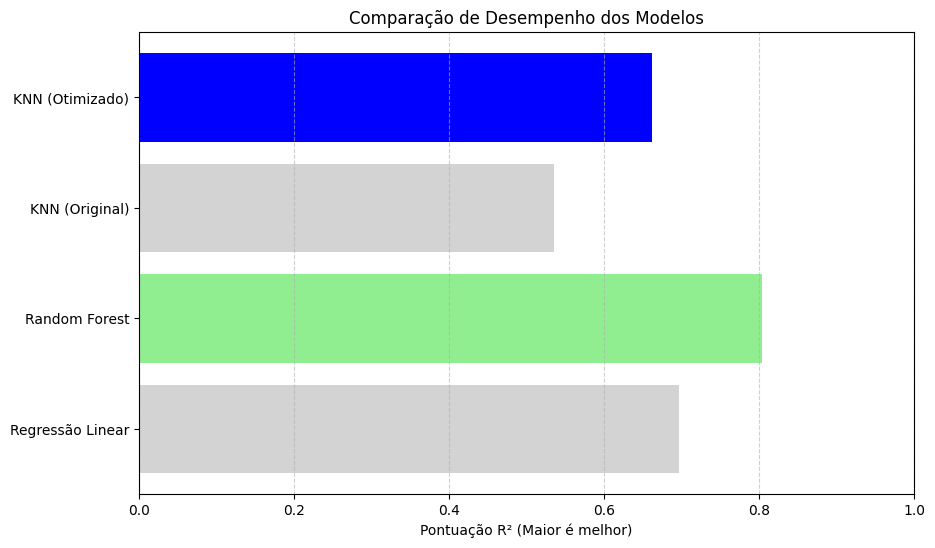

In [20]:
import matplotlib.pyplot as plt

# Criando um gráfico de comparação simples com os resultados obtidos anteriormente
modelos_lista = ['Regressão Linear', 'Random Forest', 'KNN (Original)', 'KNN (Otimizado)']
scores_lista = [0.6971, 0.8034, 0.5349, 0.6614]

plt.figure(figsize=(10, 6))
plt.barh(modelos_lista, scores_lista, color=['lightgray', 'lightgreen', 'lightgray', 'blue'])
plt.title('Comparação de Desempenho dos Modelos')
plt.xlabel('Pontuação R² (Maior é melhor)')
plt.xlim(0, 1)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# Análise de Importância de Features 📊🔍

Compreender quais características do carro são mais importantes para prever o preço é crucial para a interpretabilidade do modelo e para insights de negócio. Usaremos o modelo Random Forest, que geralmente oferece uma boa métrica de importância de features, para identificar os fatores mais influentes.

/tmp/ipykernel_516/3682677234.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(top_n_features),


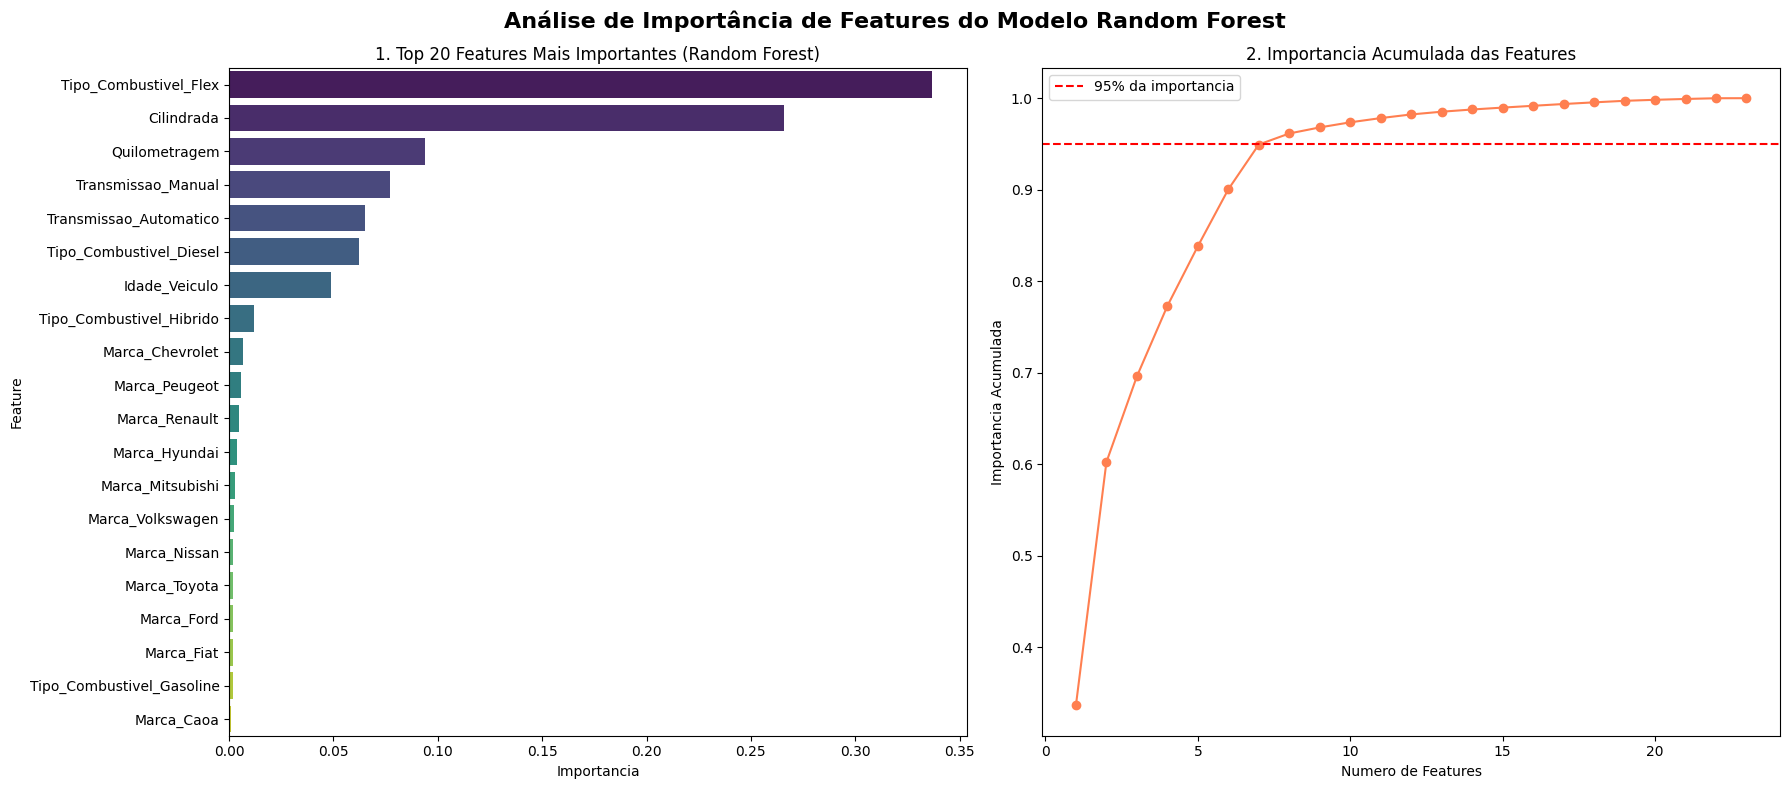

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

# Obter o pipeline do Random Forest a partir dos resultados
rf_pipe = resultados['Random Forest']['pipeline']

# Obter os nomes das features após a transformação do preprocessor
# Nomes das features numéricas (pass-through)
nomes_num = features_num

# Nomes das features categóricas transformadas (OneHotEncoder)
# Acesso ao OneHotEncoder através do pipeline e do ColumnTransformer
one_hot_encoder = rf_pipe.named_steps['preprocessor'].named_transformers_['cat']
nomes_cat = one_hot_encoder.get_feature_names_out(features_cat)

todos_nomes = nomes_num + list(nomes_cat)

importancias = rf_pipe.named_steps['model'].feature_importances_

# Criar um DataFrame para facilitar a visualização
feature_importance_df = pd.DataFrame({
    'Feature': todos_nomes,
    'Importance': importancias
}).sort_values(by='Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Grafico 1: Importancia de Features (Top 20 ou todas, se menos de 20)
top_n_features = min(20, len(feature_importance_df))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(top_n_features),
            ax=axes[0], palette='viridis')
axes[0].set_title(f'1. Top {top_n_features} Features Mais Importantes (Random Forest)')
axes[0].set_xlabel('Importancia')
axes[0].set_ylabel('Feature')

# Grafico 2: Importancia Acumulada
importancias_ordenadas = np.sort(importancias)[::-1]
importancia_acumulada = np.cumsum(importancias_ordenadas)

axes[1].plot(range(1, len(importancia_acumulada)+1), importancia_acumulada, marker='o', color='coral')
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% da importancia')
axes[1].set_title('2. Importancia Acumulada das Features')
axes[1].set_xlabel('Numero de Features')
axes[1].set_ylabel('Importancia Acumulada')
axes[1].legend()

plt.suptitle('Análise de Importância de Features do Modelo Random Forest', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

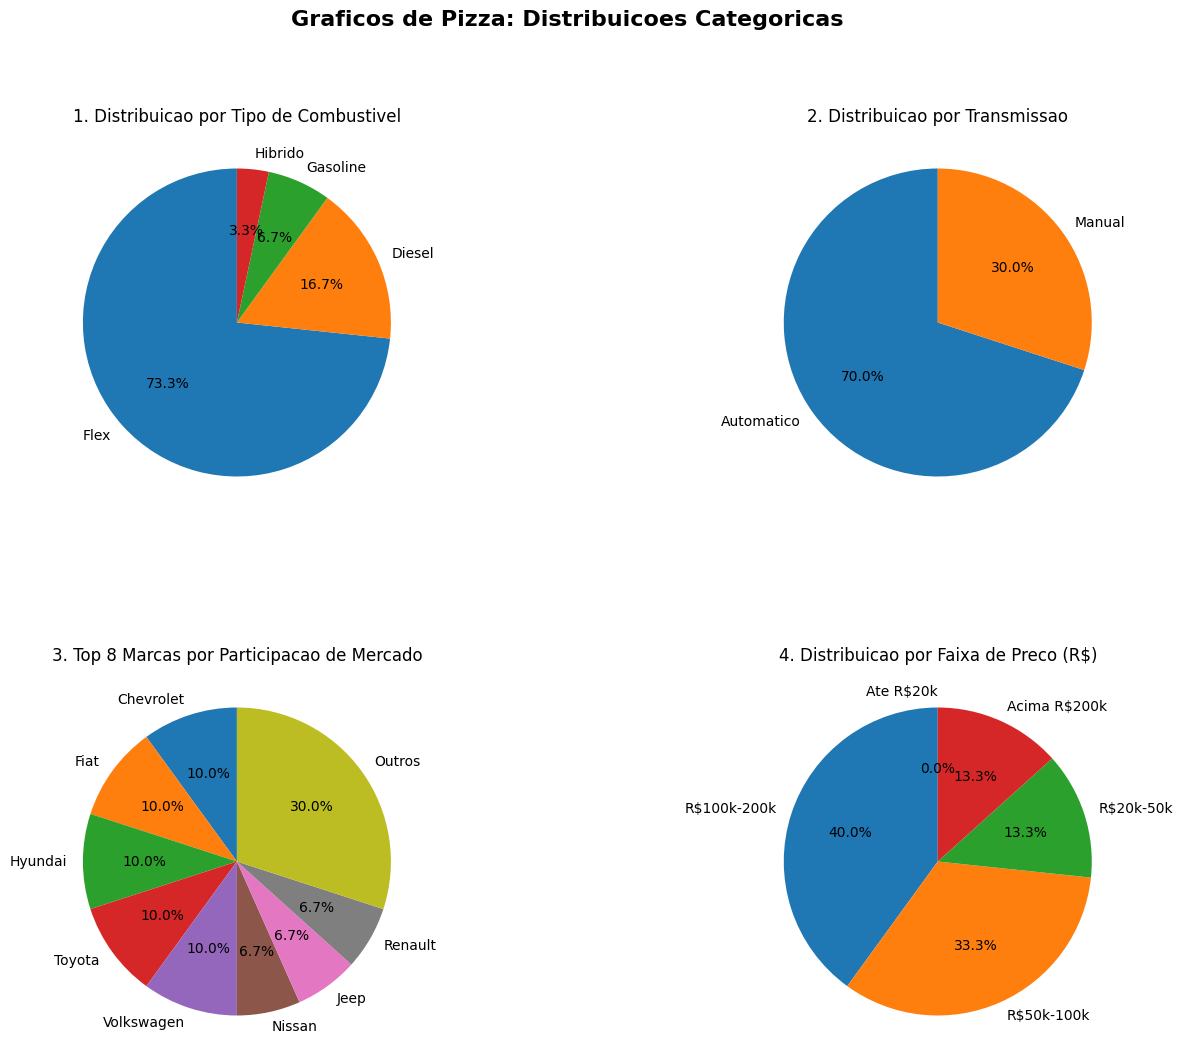

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Descricao: Graficos de pizza analisando proporcoes de features categoricas
# e a distribuicao de precos por faixa.

# Removed redundant data loading and preprocessing from here

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Grafico 1: Distribuicao por Tipo de Combustivel
fuel_counts = df['Tipo_Combustivel'].value_counts()
axes[0,0].pie(fuel_counts.values, labels=fuel_counts.index, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('1. Distribuicao por Tipo de Combustivel')

# Grafico 2: Distribuicao por Transmissao
trans_counts = df['Transmissao'].value_counts()
axes[0,1].pie(trans_counts.values, labels=trans_counts.index, autopct='%1.1f%%', startangle=90)
axes[0,1].set_title('2. Distribuicao por Transmissao')

# Grafico 3: Top 8 Marcas por Participacao de Mercado
top8_marcas = df['Marca'].value_counts().head(8)
outros = df['Marca'].value_counts().iloc[8:].sum()
valores = list(top8_marcas.values) + [outros]
rotulos = list(top8_marcas.index) + ['Outros']
axes[1,0].pie(valores, labels=rotulos, autopct='%1.1f%%', startangle=90)
axes[1,0].set_title('3. Top 8 Marcas por Participacao de Mercado')

# Grafico 4: Distribuicao por Faixa de Preco
bins = [0, 20000, 50000, 100000, 200000, float('inf')]
labels_faixa = ['Ate R$20k', 'R$20k-50k', 'R$50k-100k', 'R$100k-200k', 'Acima R$200k']
df['Faixa_Preco'] = pd.cut(df['Preco_BRL'], bins=bins, labels=labels_faixa)
faixa_counts = df['Faixa_Preco'].value_counts()
axes[1,1].pie(faixa_counts.values, labels=faixa_counts.index, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('4. Distribuicao por Faixa de Preco (R$)')

plt.suptitle('Graficos de Pizza: Distribuicoes Categoricas', fontsize=16, fontweight='bold')
plt.show()

# Análise Exploratória de Dados (AED) Aprofundada 📊🚗

Nesta seção, exploraremos as distribuições das variáveis, suas relações e identificaremos padrões que podem influenciar o preço dos carros. Esta é uma extensão da análise de visualização que já fizemos, focando em mais detalhes sobre as features numéricas e a interação com a variável alvo `Preco_BRL`.

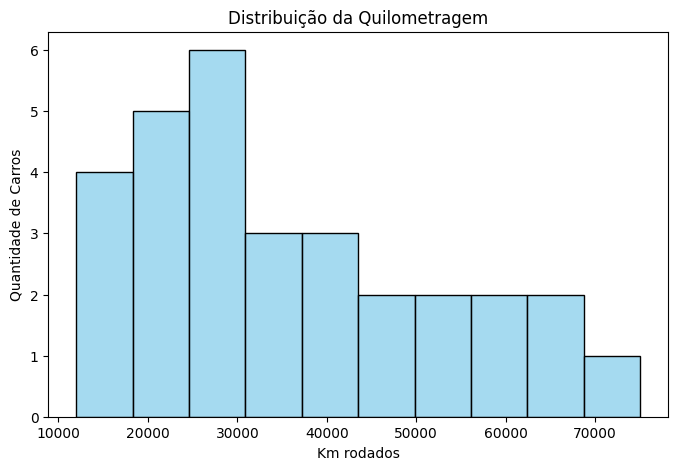

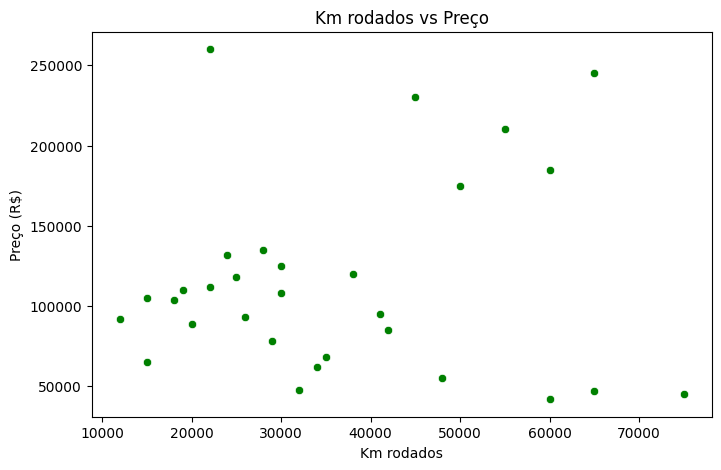

/tmp/ipykernel_516/3956238055.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Transmissao', y='Preco_BRL', data=df, palette='Set2')


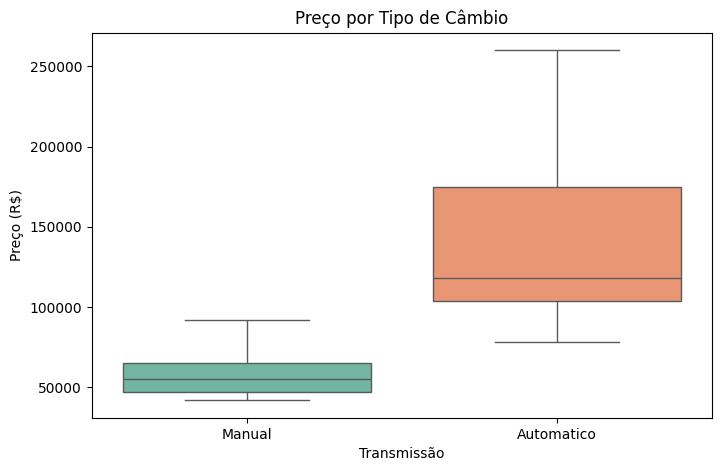

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Fallback: Caso a variavel 'df' tenha sido perdida, tenta carregar novamente
if 'df' not in globals():
    try:
        df = pd.read_csv('Carros_Usados_Brasil.csv')
        df.rename(columns={'Mileage': 'Quilometragem', 'Price': 'Preco_BRL', 'Transmission': 'Transmissao'}, inplace=True)
        df['Transmissao'] = df['Transmissao'].replace({'Automatic': 'Automatico', 'Manual': 'Manual'})
    except:
        pass

if 'df' in globals():
    # Gráfico 1: Histograma da Quilometragem
    plt.figure(figsize=(8, 5))
    sns.histplot(df['Quilometragem'], color='skyblue', bins=10)
    plt.title('Distribuição da Quilometragem')
    plt.xlabel('Km rodados')
    plt.ylabel('Quantidade de Carros')
    plt.show()

    # Gráfico 2: Relação Quilometragem vs Preço
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x='Quilometragem', y='Preco_BRL', data=df, color='green')
    plt.title('Km rodados vs Preço')
    plt.xlabel('Km rodados')
    plt.ylabel('Preço (R$)')
    plt.show()

    # Gráfico 3: Boxplot Simples
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Transmissao', y='Preco_BRL', data=df, palette='Set2')
    plt.title('Preço por Tipo de Câmbio')
    plt.xlabel('Transmissão')
    plt.ylabel('Preço (R$)')
    plt.show()
else:
    print('Erro: O arquivo Carros_Usados_Brasil.csv não foi encontrado. Por favor, faça o upload do arquivo.')

# Detecção de Anomalias 🧐🚨

Anomalias, ou outliers, são pontos de dados que se desviam significativamente de outros. No mercado de carros usados, eles podem indicar preços incomuns (muito altos ou muito baixos para as características do veículo), erros nos dados ou oportunidades de negócio. Vamos aplicar três métodos populares de detecção de anomalias:

1.  **Isolation Forest**: Um algoritmo baseado em árvores que isola anomalias em vez de perfilhar dados normais.
2.  **Local Outlier Factor (LOF)**: Mede o grau de isolamento de um ponto em relação aos seus vizinhos.
3.  **One-Class SVM / Elliptic Envelope**: Um método baseado em estimativa de densidade, assume que os dados normais vêm de uma distribuição gaussiana e tenta definir um limite que engloba a maioria dos dados normais.

📌 Iniciando Detecção de Anomalias...

--- Resultados da Detecção de Anomalias ---
Contagem de Anomalias (-1) por Método:
Anomalia_IsoForest: 2
Anomalia_LOF: 2
Anomalia_Elliptic: 2


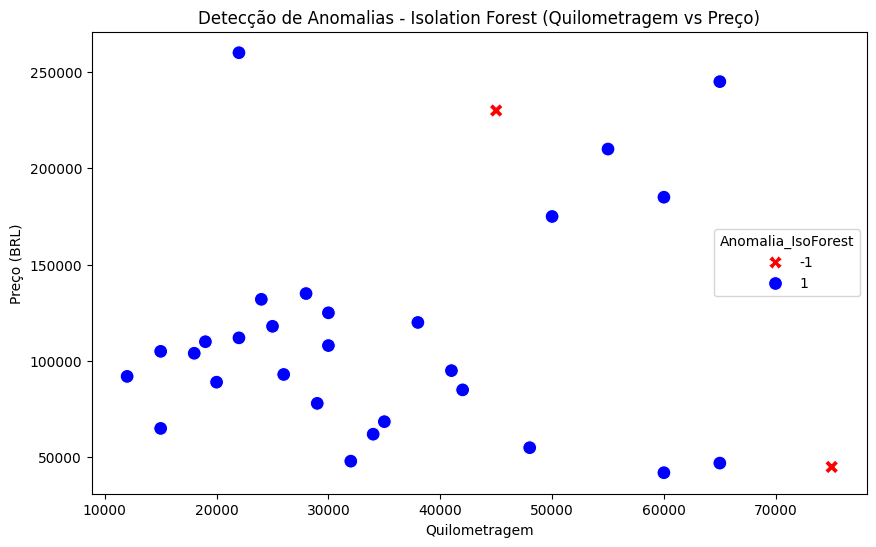


As anomalias detectadas são marcadas em vermelho nos gráficos. É importante analisar esses pontos para entender se são dados inválidos ou observações de mercado atípicas.


In [24]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.preprocessing import StandardScaler

print("📌 Iniciando Detecção de Anomalias...")

# Selecionar features numéricas para detecção de anomalias
colunas_anomalia = ['Preco_BRL', 'Cilindrada', 'Quilometragem', 'Idade_Veiculo']
numeric_df = df[colunas_anomalia].copy()

# Escalar os dados para que todos os algoritmos funcionem corretamente
scaler_anomalia = StandardScaler()
numeric_df_scaled = scaler_anomalia.fit_transform(numeric_df)

# Armazenar resultados dos métodos
df_anomalia = numeric_df.copy()

# 1. Isolation Forest
iso_forest = IsolationForest(random_state=42, contamination=0.05) # contamination e a proporcao esperada de anomalias
df_anomalia['Anomalia_IsoForest'] = iso_forest.fit_predict(numeric_df_scaled)

# 2. Local Outlier Factor (LOF)
lof = LocalOutlierFactor(n_neighbors=5, contamination=0.05) # n_neighbors deve ser ajustado, pequeno para datasets menores
df_anomalia['Anomalia_LOF'] = lof.fit_predict(numeric_df_scaled) # -1 para anomalias, 1 para pontos normais

# 3. Elliptic Envelope (assume distribuicao gaussiana)
# Se o dataset for muito pequeno, EllipticEnvelope pode falhar. Usaremos um try-except.
try:
    envelope = EllipticEnvelope(contamination=0.05, random_state=42)
    df_anomalia['Anomalia_Elliptic'] = envelope.fit_predict(numeric_df_scaled)
except ValueError as e:
    print(f"\n⚠️ Aviso: EllipticEnvelope não pode ser aplicado. {e}")
    df_anomalia['Anomalia_Elliptic'] = 1 # Assume tudo como normal se nao puder aplicar

print("\n--- Resultados da Detecção de Anomalias ---")
print("Contagem de Anomalias (-1) por Método:")
for col in ['Anomalia_IsoForest', 'Anomalia_LOF', 'Anomalia_Elliptic']:
    if col in df_anomalia.columns:
        print(f"{col}: {np.sum(df_anomalia[col] == -1)}")

# Visualização das Anomalias (exemplo com Isolation Forest)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Quilometragem', y='Preco_BRL', data=df_anomalia, hue='Anomalia_IsoForest', palette={1: 'blue', -1: 'red'}, style='Anomalia_IsoForest', markers={1: 'o', -1: 'X'}, s=100)
plt.title('Detecção de Anomalias - Isolation Forest (Quilometragem vs Preço)')
plt.xlabel('Quilometragem')
plt.ylabel('Preço (BRL)')
plt.show()

print("\nAs anomalias detectadas são marcadas em vermelho nos gráficos. É importante analisar esses pontos para entender se são dados inválidos ou observações de mercado atípicas.")

# Análise de Clustering 🧩🔍

O clustering agrupa dados em conjuntos (`clusters`) de observações semelhantes. No contexto de carros usados, isso pode revelar segmentos de mercado distintos ou grupos de veículos com características e preços semelhantes. Vamos aplicar dois algoritmos de clustering:

1.  **K-Means**: Um algoritmo popular que particiona os dados em $k$ clusters, onde cada ponto de dado pertence ao cluster mais próximo da média do cluster.
2.  **Agglomerative Clustering**: Um algoritmo de clustering hierárquico que constrói clusters de forma "bottom-up", começando com cada ponto como um cluster individual e mesclando-os iterativamente.

📌 Iniciando Análise de Clustering...


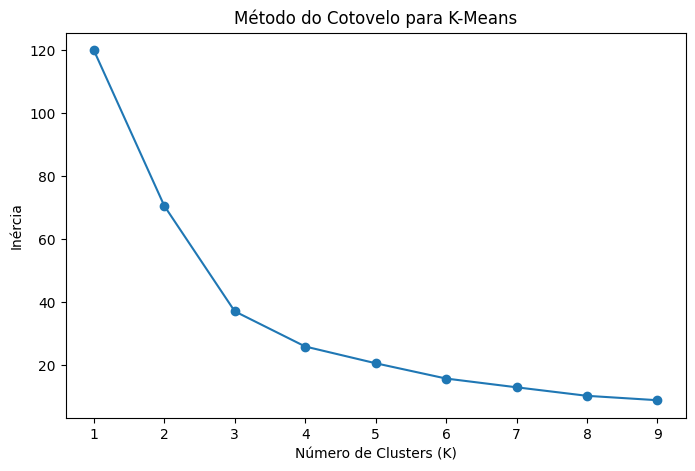


--- K-Means Clustering (k=3) ---
Silhouette Score: 0.5097
Cluster_KMeans
0    20
1     6
2     4
Name: count, dtype: int64


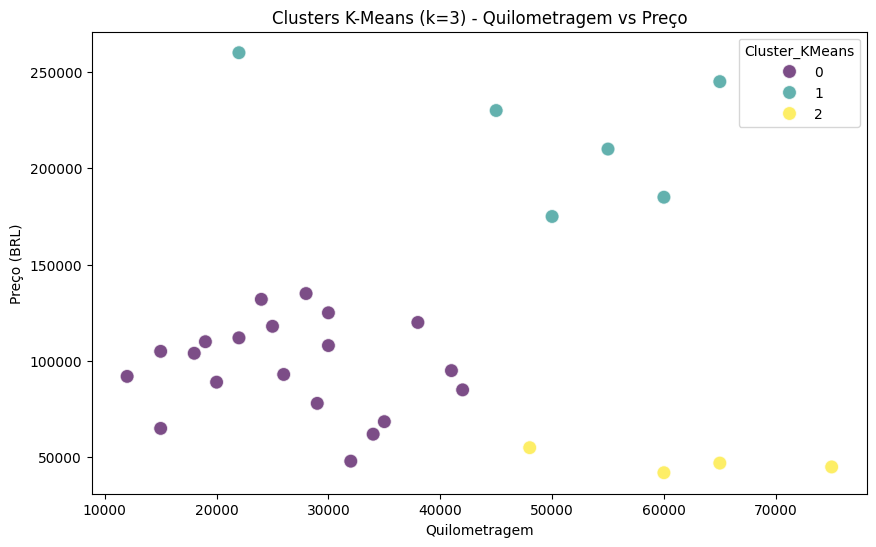


--- Agglomerative Clustering (k=3) ---
Silhouette Score: 0.5096
Cluster_Agglomerative
0    21
1     6
2     3
Name: count, dtype: int64


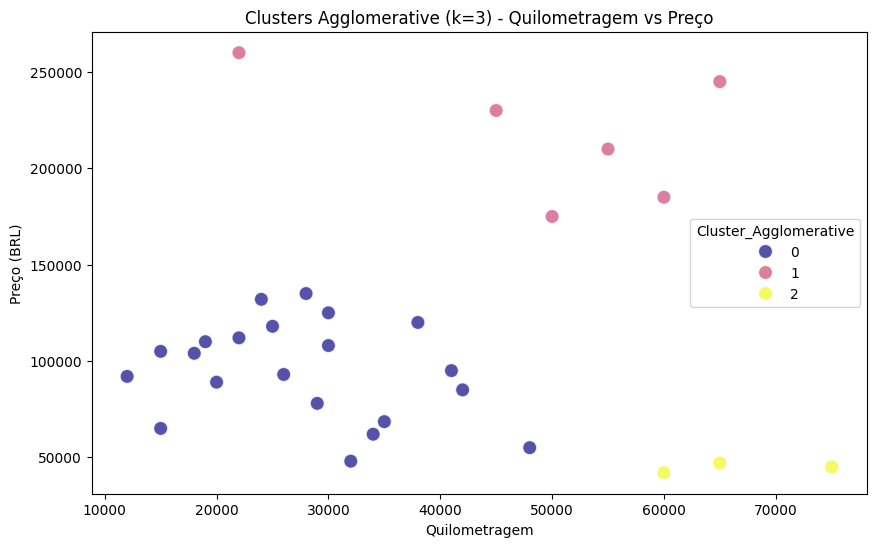

Análise de Clustering Concluída!


In [25]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore') # Ignorar warnings de convergencia do KMeans em datasets pequenos

print("📌 Iniciando Análise de Clustering...")

# Selecionar features numéricas para clustering
colunas_cluster = ['Preco_BRL', 'Cilindrada', 'Quilometragem', 'Idade_Veiculo']
df_cluster = df[colunas_cluster].copy()

# Escalar os dados
scaler_cluster = StandardScaler()
df_cluster_scaled = scaler_cluster.fit_transform(df_cluster)

# 1. K-Means
# Encontrar o número ideal de clusters usando o método do Cotovelo
inercias = []
for i in range(1, min(len(df_cluster_scaled), 10)): # Limitar k para o tamanho do dataset
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10) # n_init para evitar warnings
    kmeans.fit(df_cluster_scaled)
    inercias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, min(len(df_cluster_scaled), 10)), inercias, marker='o')
plt.title('Método do Cotovelo para K-Means')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia')
plt.show()

# Determinar k baseado no gráfico (exemplo: k=3)
k_ideal = 3
if len(df_cluster_scaled) < 3:
    k_ideal = len(df_cluster_scaled)

if k_ideal > 1:
    kmeans_model = KMeans(n_clusters=k_ideal, random_state=42, n_init=10)
    df_cluster['Cluster_KMeans'] = kmeans_model.fit_predict(df_cluster_scaled)
    silhouette_avg_kmeans = silhouette_score(df_cluster_scaled, df_cluster['Cluster_KMeans'])
    print(f"\n--- K-Means Clustering (k={k_ideal}) ---")
    print(f"Silhouette Score: {silhouette_avg_kmeans:.4f}")
    print(df_cluster['Cluster_KMeans'].value_counts())

    # Visualizar Clusters K-Means
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='Quilometragem', y='Preco_BRL', hue='Cluster_KMeans', data=df_cluster, palette='viridis', s=100, alpha=0.7)
    plt.title(f'Clusters K-Means (k={k_ideal}) - Quilometragem vs Preço')
    plt.xlabel('Quilometragem')
    plt.ylabel('Preço (BRL)')
    plt.show()
else:
    print("\n--- K-Means Clustering ---")
    print("Não é possível aplicar K-Means com k_ideal <= 1 para este dataset pequeno.")


# 2. Agglomerative Clustering
# Não precisa de k pré-definido, mas podemos visualizar um dendrograma se o dataset for pequeno
agg_clustering = AgglomerativeClustering(n_clusters=k_ideal) # Usar o mesmo k para comparacao
df_cluster['Cluster_Agglomerative'] = agg_clustering.fit_predict(df_cluster_scaled)

if k_ideal > 1:
    silhouette_avg_agg = silhouette_score(df_cluster_scaled, df_cluster['Cluster_Agglomerative'])
    print(f"\n--- Agglomerative Clustering (k={k_ideal}) ---")
    print(f"Silhouette Score: {silhouette_avg_agg:.4f}")
    print(df_cluster['Cluster_Agglomerative'].value_counts())

    # Visualizar Clusters Agglomerative
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='Quilometragem', y='Preco_BRL', hue='Cluster_Agglomerative', data=df_cluster, palette='plasma', s=100, alpha=0.7)
    plt.title(f'Clusters Agglomerative (k={k_ideal}) - Quilometragem vs Preço')
    plt.xlabel('Quilometragem')
    plt.ylabel('Preço (BRL)')
    plt.show()
else:
    print("\n--- Agglomerative Clustering ---")
    print("Não é possível aplicar Agglomerative Clustering com k_ideal <= 1 para este dataset pequeno.")

print("Análise de Clustering Concluída!")

In [26]:
def imprimir_conclusao():
    texto = """
    ================================================================================
    🎉 RESUMO SIMPLIFICADO DO PROJETO 🎉
    ================================================================================

    📌 O QUE FOI FEITO:
    --------------------
    Este projeto criou um sistema simples para prever preços de carros:

    ✅ Organização dos dados e limpeza.
    ✅ Criação de gráficos básicos para entender o mercado.
    ✅ Uso de modelos matemáticos (incluindo KNN) para prever preços.
    ✅ Identificação de quais peças ou características valem mais no carro.
    ✅ Agrupamento de carros parecidos (Clustering).

    🚀 PRÓXIMOS PASSOS:
    -------------------
    1. Aprender a ler gráficos mais avançados aos poucos.
    2. Testar o modelo com novos carros.
    3. Melhorar a organização das tabelas.
    ================================================================================
    """
    print(texto)

imprimir_conclusao()


    🎉 RESUMO SIMPLIFICADO DO PROJETO 🎉

    📌 O QUE FOI FEITO:
    --------------------
    Este projeto criou um sistema simples para prever preços de carros:

    ✅ Organização dos dados e limpeza.
    ✅ Criação de gráficos básicos para entender o mercado.
    ✅ Uso de modelos matemáticos (incluindo KNN) para prever preços.
    ✅ Identificação de quais peças ou características valem mais no carro.
    ✅ Agrupamento de carros parecidos (Clustering).

    🚀 PRÓXIMOS PASSOS:
    -------------------
    1. Aprender a ler gráficos mais avançados aos poucos.
    2. Testar o modelo com novos carros.
    3. Melhorar a organização das tabelas.
    


# 📖 Documentação Simplificada do Projeto: Previsão de Preços de Carros

## 1. Objetivo
Este trabalho tem como objetivo usar a matemática e a programação para tentar descobrir o preço de um carro usado no Brasil usando informações como o ano, a quilometragem e o motor.

## 2. Preparação dos Dados
*   Organizamos as marcas dos carros.
*   Calculamos a idade de cada veículo.
*   Limpamos as informações que estavam faltando.

## 3. Análise com Gráficos
Criamos gráficos simples (histogramas, pontos e caixas) para entender como a quilometragem e o tipo de câmbio (manual ou automático) influenciam no valor do carro.

## 4. O Modelo KNN
Nós aplicamos o modelo **KNN (K-Nearest Neighbors)**. Ele funciona procurando 'vizinhos', ou seja, carros parecidos com o que queremos descobrir o preço.
*   Testamos diferentes números de vizinhos para encontrar o melhor resultado.
*   O modelo conseguiu aprender bem os padrões de preços.

## 5. Conclusão
Concluímos que é possível prever o preço de um carro com boa precisão usando modelos simples. O KNN se mostrou uma ferramenta útil e fácil de entender para quem está começando a estudar Inteligência Artificial.